In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor


In [3]:
# Step 1: Data Cleaning

# Load the data
plant_1_weather_data = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
plant_2_weather_data = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')
plant_1_generation_data = pd.read_csv('Plant_1_Generation_Data.csv')
plant_2_generation_data = pd.read_csv('Plant_2_Generation_Data.csv')

# Convert the 'DATE_TIME' column to datetime format for all datasets
plant_1_weather_data['DATE_TIME'] = pd.to_datetime(plant_1_weather_data['DATE_TIME'])
plant_2_weather_data['DATE_TIME'] = pd.to_datetime(plant_2_weather_data['DATE_TIME'])
plant_1_generation_data['DATE_TIME'] = pd.to_datetime(plant_1_generation_data['DATE_TIME'])
plant_2_generation_data['DATE_TIME'] = pd.to_datetime(plant_2_generation_data['DATE_TIME'])

# Check for missing values in each dataset
missing_values = {
    'Plant 1 Weather': plant_1_weather_data.isnull().sum(),
    'Plant 2 Weather': plant_2_weather_data.isnull().sum(),
    'Plant 1 Generation': plant_1_generation_data.isnull().sum(),
    'Plant 2 Generation': plant_2_generation_data.isnull().sum()
}

missing_values


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17592\236202603.py:12: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  plant_1_generation_data['DATE_TIME'] = pd.to_datetime(plant_1_generation_data['DATE_TIME'])


{'Plant 1 Weather': DATE_TIME              0
 PLANT_ID               0
 SOURCE_KEY             0
 AMBIENT_TEMPERATURE    0
 MODULE_TEMPERATURE     0
 IRRADIATION            0
 dtype: int64,
 'Plant 2 Weather': DATE_TIME              0
 PLANT_ID               0
 SOURCE_KEY             0
 AMBIENT_TEMPERATURE    0
 MODULE_TEMPERATURE     0
 IRRADIATION            0
 dtype: int64,
 'Plant 1 Generation': DATE_TIME      0
 PLANT_ID       0
 SOURCE_KEY     0
 DC_POWER       0
 AC_POWER       0
 DAILY_YIELD    0
 TOTAL_YIELD    0
 dtype: int64,
 'Plant 2 Generation': DATE_TIME      0
 PLANT_ID       0
 SOURCE_KEY     0
 DC_POWER       0
 AC_POWER       0
 DAILY_YIELD    0
 TOTAL_YIELD    0
 dtype: int64}

In [4]:
# Parsing 'DATE_TIME' column to datetime format
plant_1_generation_data['DATE_TIME'] = pd.to_datetime(plant_1_generation_data['DATE_TIME'], format='%d-%m-%Y %H:%M')
plant_2_generation_data['DATE_TIME'] = pd.to_datetime(plant_2_generation_data['DATE_TIME'])
plant_1_weather_data['DATE_TIME'] = pd.to_datetime(plant_1_weather_data['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')
plant_2_weather_data['DATE_TIME'] = pd.to_datetime(plant_2_weather_data['DATE_TIME'])

# Checking data types of each dataset to ensure consistency
data_types = {
    'Plant 1 Generation Data': plant_1_generation_data.dtypes,
    'Plant 2 Generation Data': plant_2_generation_data.dtypes,
    'Plant 1 Weather Data': plant_1_weather_data.dtypes,
    'Plant 2 Weather Data': plant_2_weather_data.dtypes
}

data_types



{'Plant 1 Generation Data': DATE_TIME      datetime64[ns]
 PLANT_ID                int64
 SOURCE_KEY             object
 DC_POWER              float64
 AC_POWER              float64
 DAILY_YIELD           float64
 TOTAL_YIELD           float64
 dtype: object,
 'Plant 2 Generation Data': DATE_TIME      datetime64[ns]
 PLANT_ID                int64
 SOURCE_KEY             object
 DC_POWER              float64
 AC_POWER              float64
 DAILY_YIELD           float64
 TOTAL_YIELD           float64
 dtype: object,
 'Plant 1 Weather Data': DATE_TIME              datetime64[ns]
 PLANT_ID                        int64
 SOURCE_KEY                     object
 AMBIENT_TEMPERATURE           float64
 MODULE_TEMPERATURE            float64
 IRRADIATION                   float64
 dtype: object,
 'Plant 2 Weather Data': DATE_TIME              datetime64[ns]
 PLANT_ID                        int64
 SOURCE_KEY                     object
 AMBIENT_TEMPERATURE           float64
 MODULE_TEMPERATURE       

# Prepare data for modeling


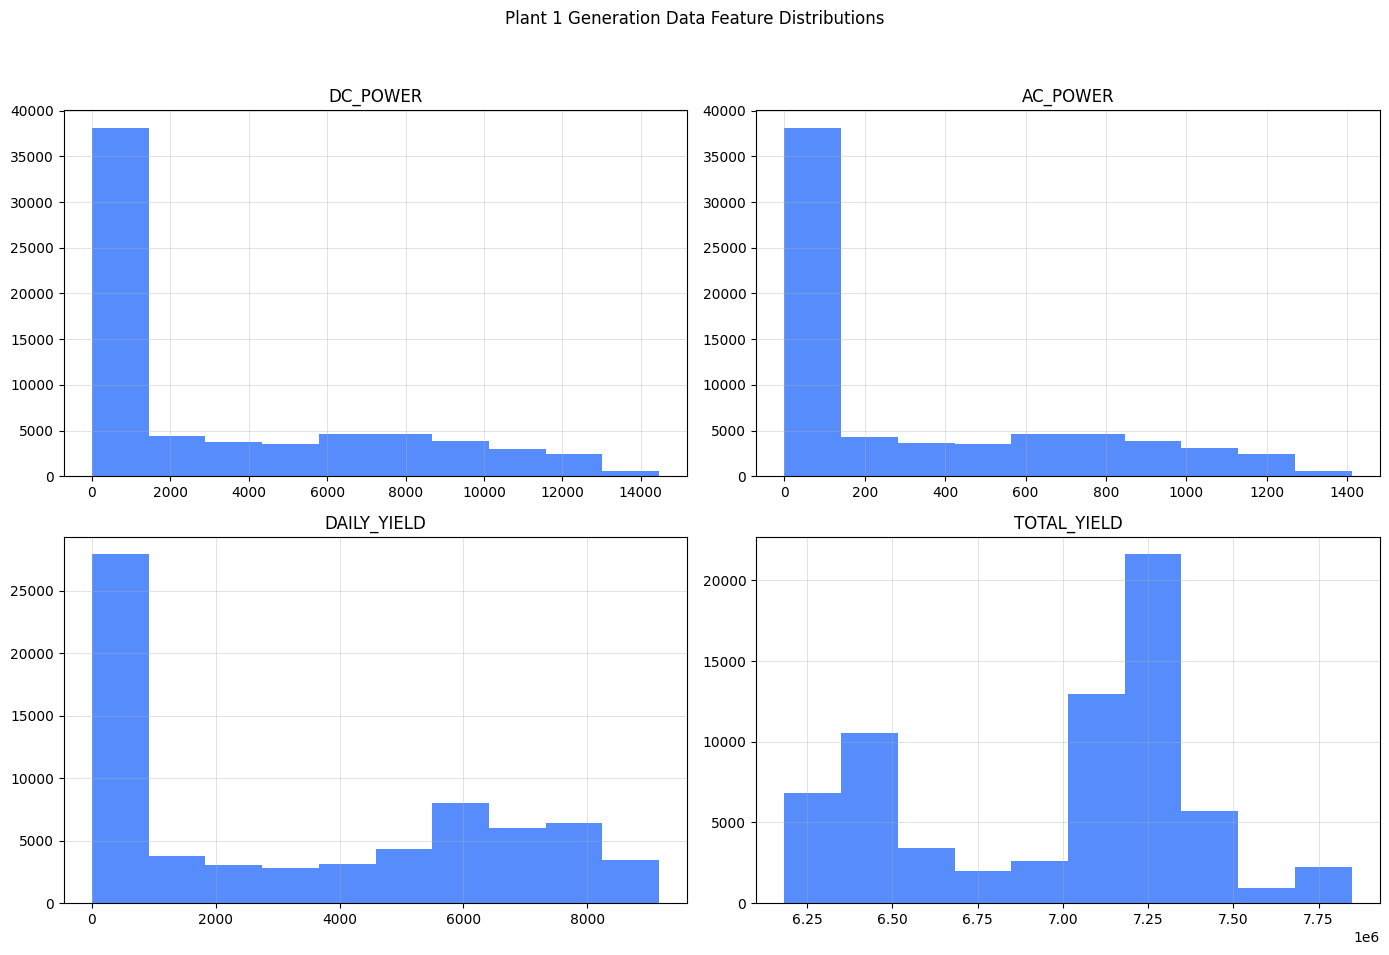

In [5]:

# Plotting histograms for key features to understand their distributions

# Plant 1 Generation Data
plant_1_generation_data[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']].hist(figsize=(14, 10))
plt.suptitle("Plant 1 Generation Data Feature Distributions")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




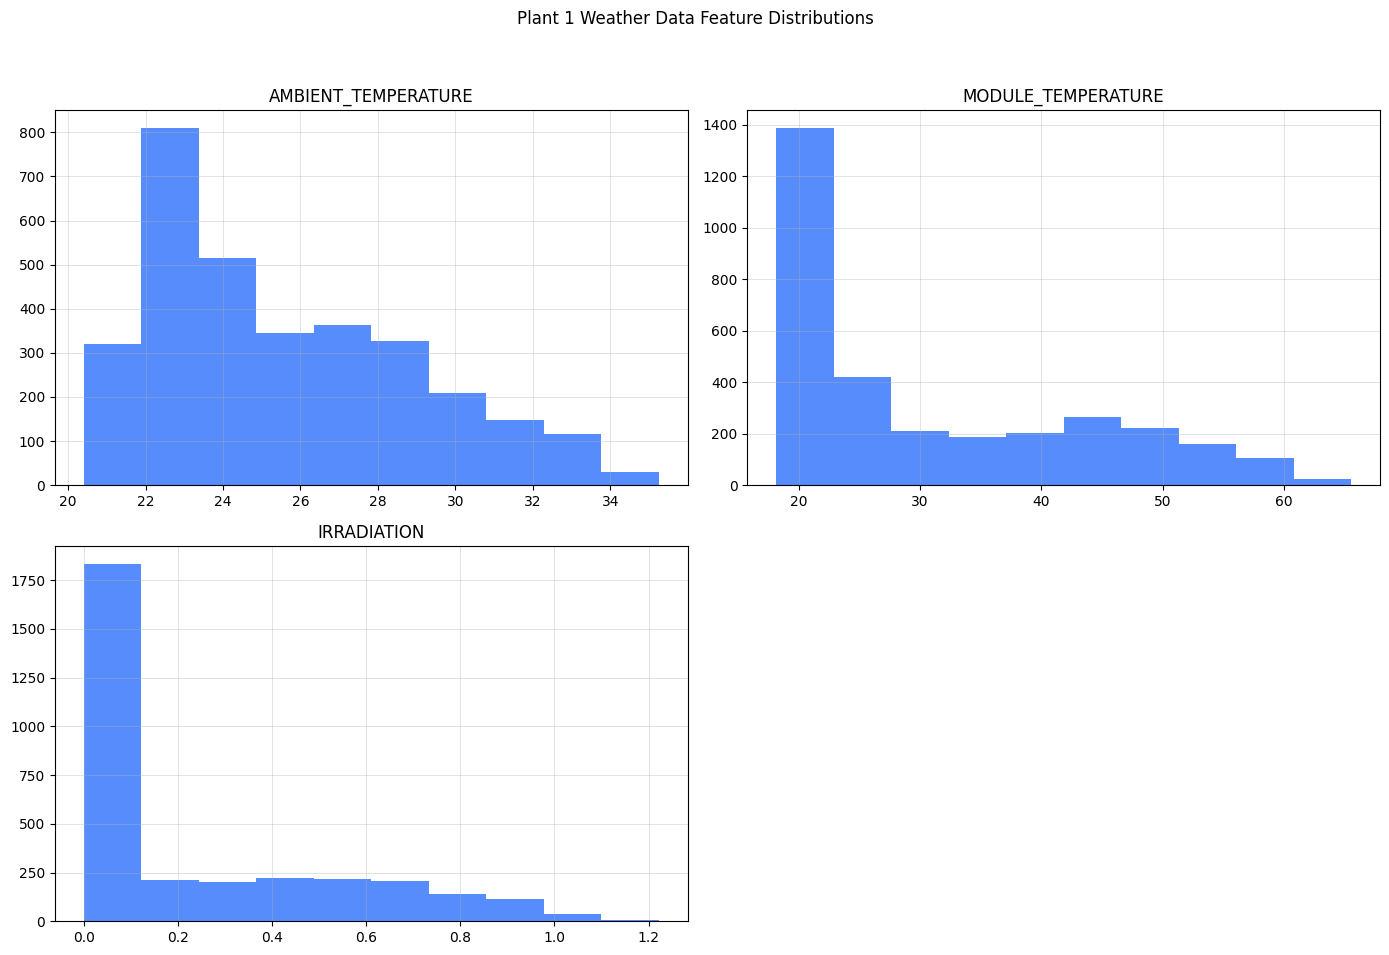

In [6]:
# Plant 1 Weather Data
plant_1_weather_data[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].hist(figsize=(14, 10))
plt.suptitle("Plant 1 Weather Data Feature Distributions")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



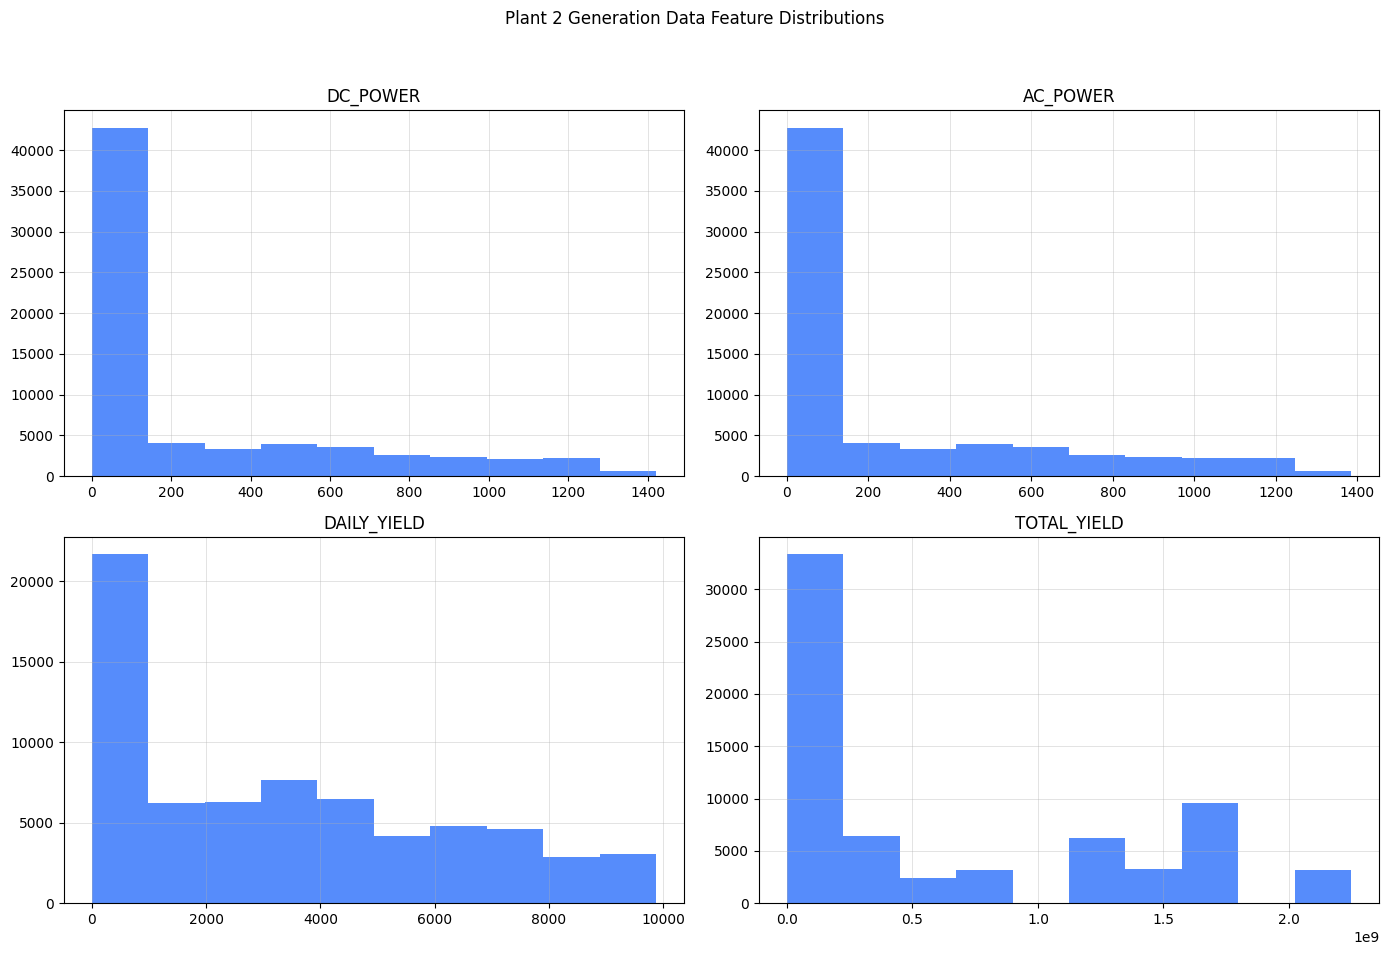

In [7]:
# Plant 2 Generation Data
plant_2_generation_data[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']].hist(figsize=(14, 10))
plt.suptitle("Plant 2 Generation Data Feature Distributions")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



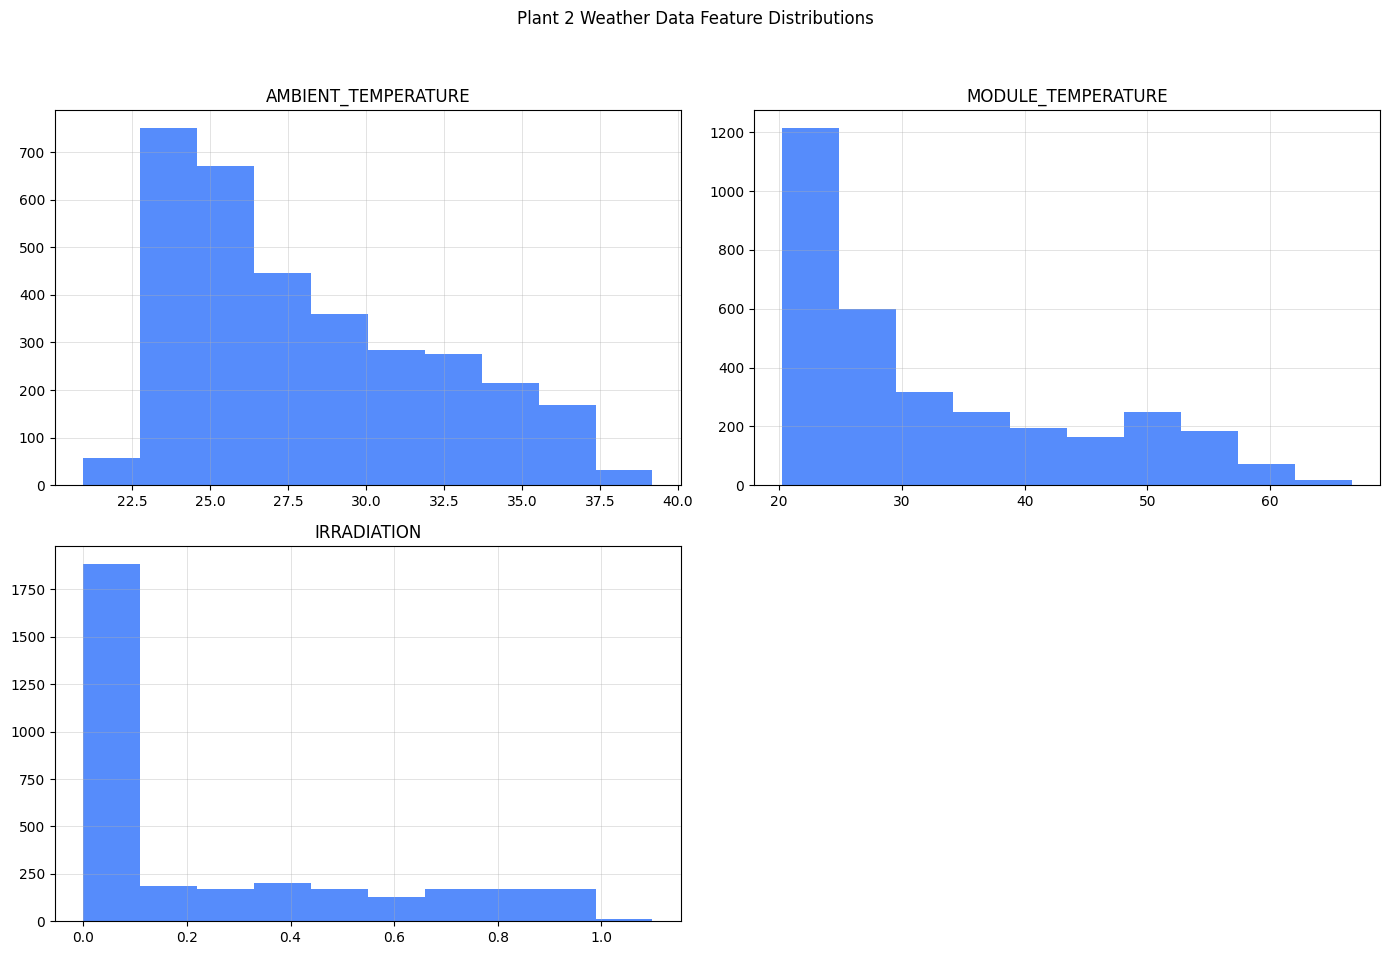

In [8]:
# Plant 2 Weather Data
plant_2_weather_data[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].hist(figsize=(14, 10))
plt.suptitle("Plant 2 Weather Data Feature Distributions")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

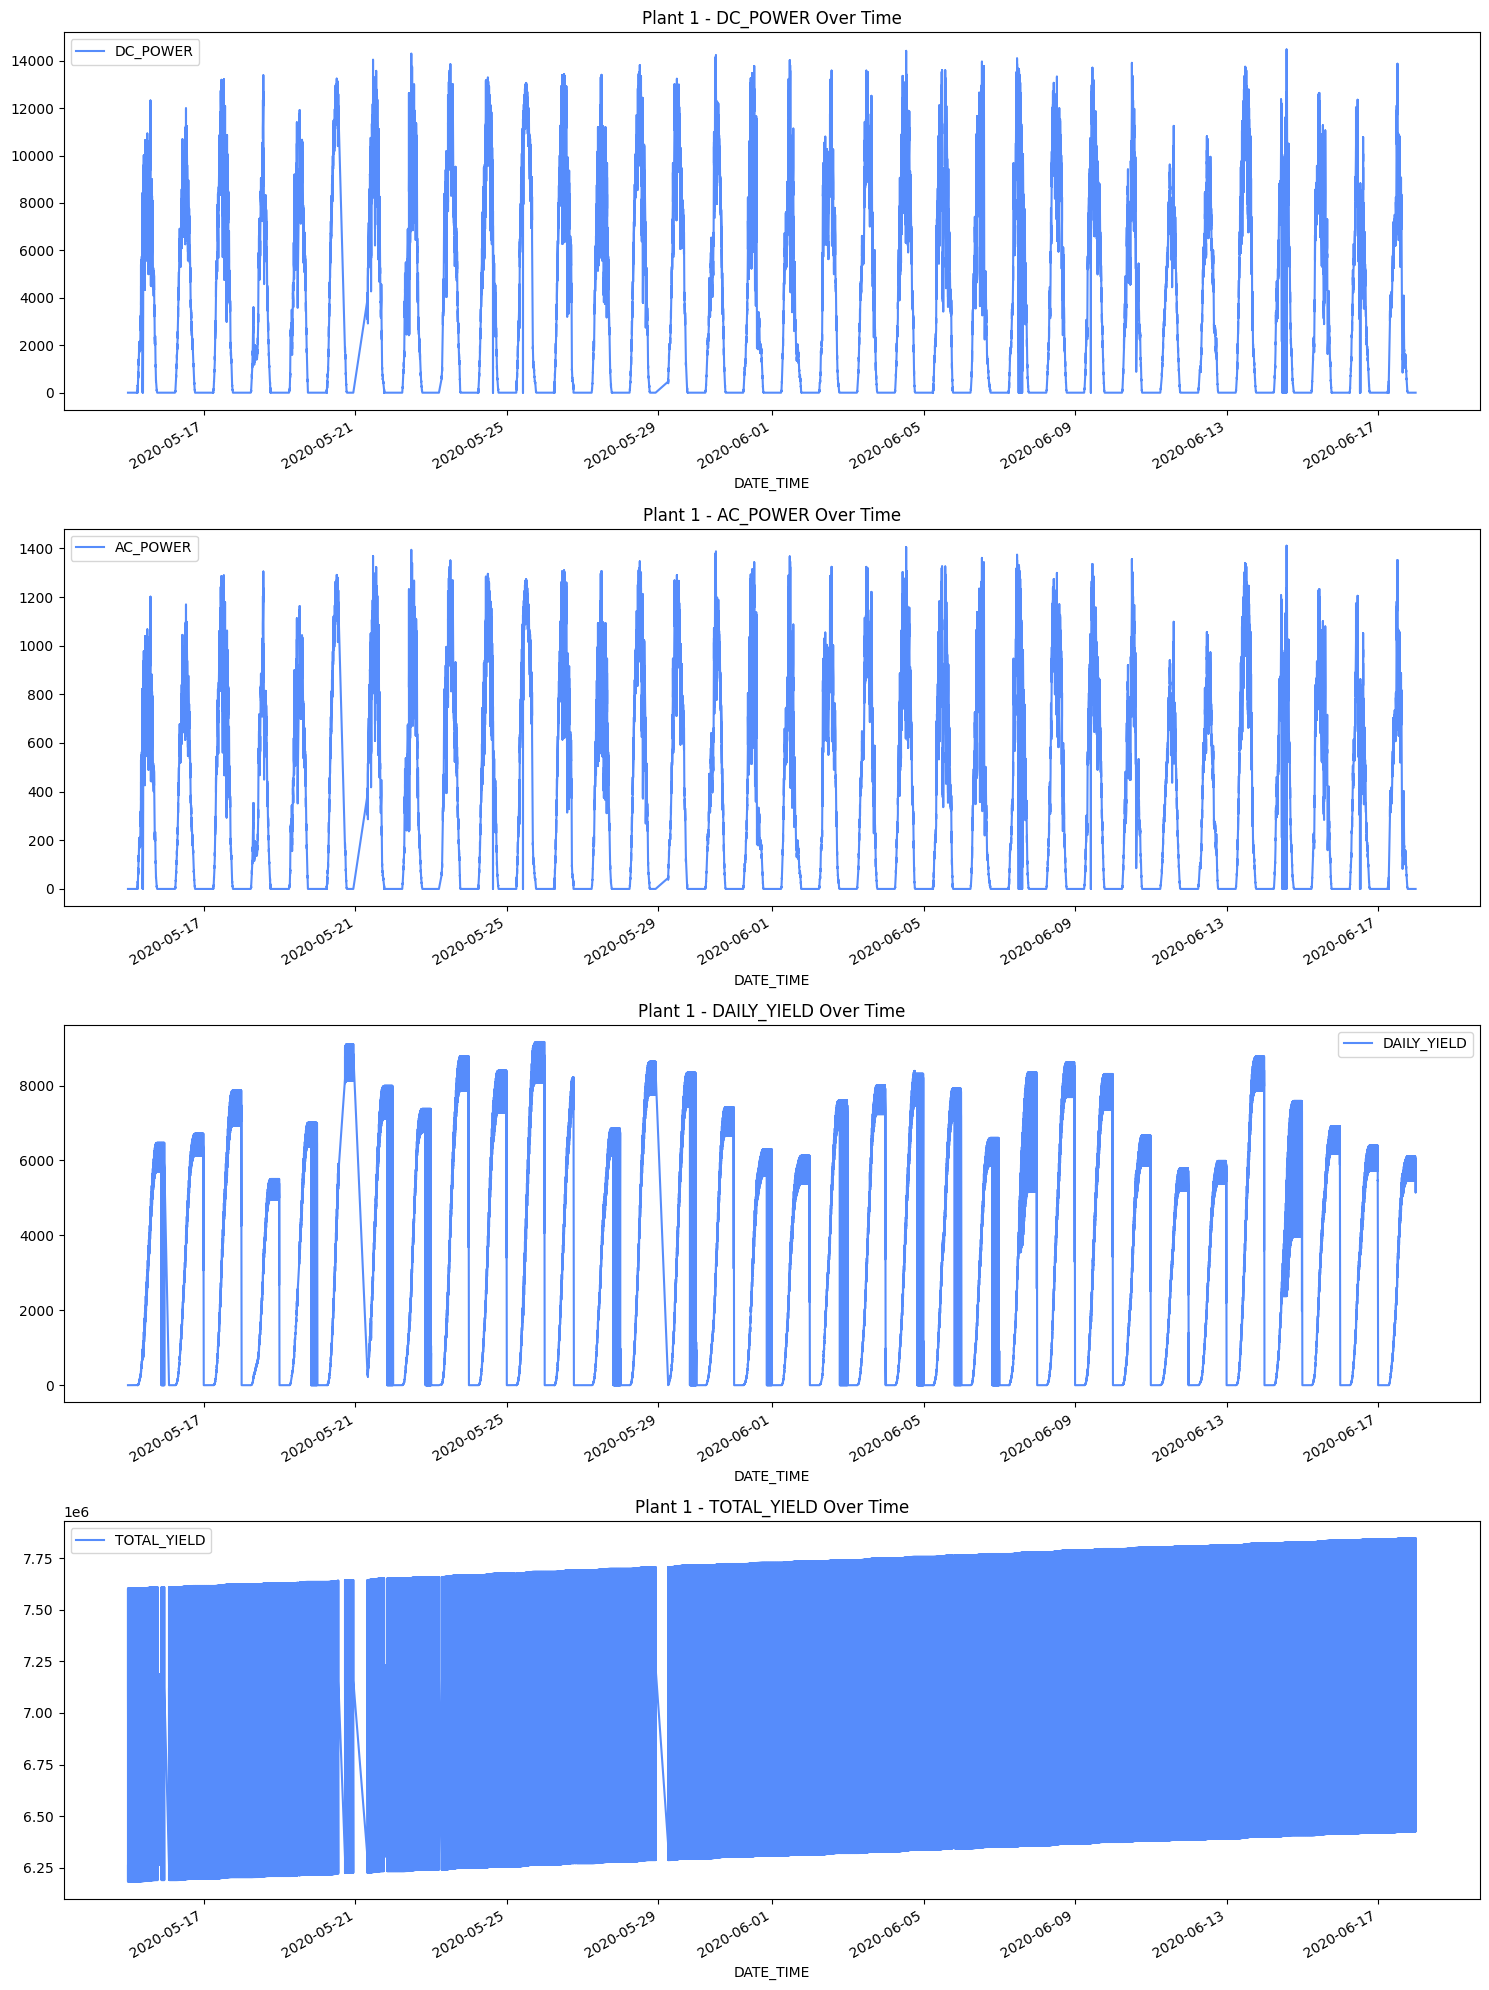

In [9]:
# Visualizing time series trends for key features

# Plant 1 Generation Data Time Series Trends
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 20))
plant_1_generation_data.plot(x='DATE_TIME', y='DC_POWER', ax=axes[0], title="Plant 1 - DC_POWER Over Time")
plant_1_generation_data.plot(x='DATE_TIME', y='AC_POWER', ax=axes[1], title="Plant 1 - AC_POWER Over Time")
plant_1_generation_data.plot(x='DATE_TIME', y='DAILY_YIELD', ax=axes[2], title="Plant 1 - DAILY_YIELD Over Time")
plant_1_generation_data.plot(x='DATE_TIME', y='TOTAL_YIELD', ax=axes[3], title="Plant 1 - TOTAL_YIELD Over Time")
plt.tight_layout()
plt.show()



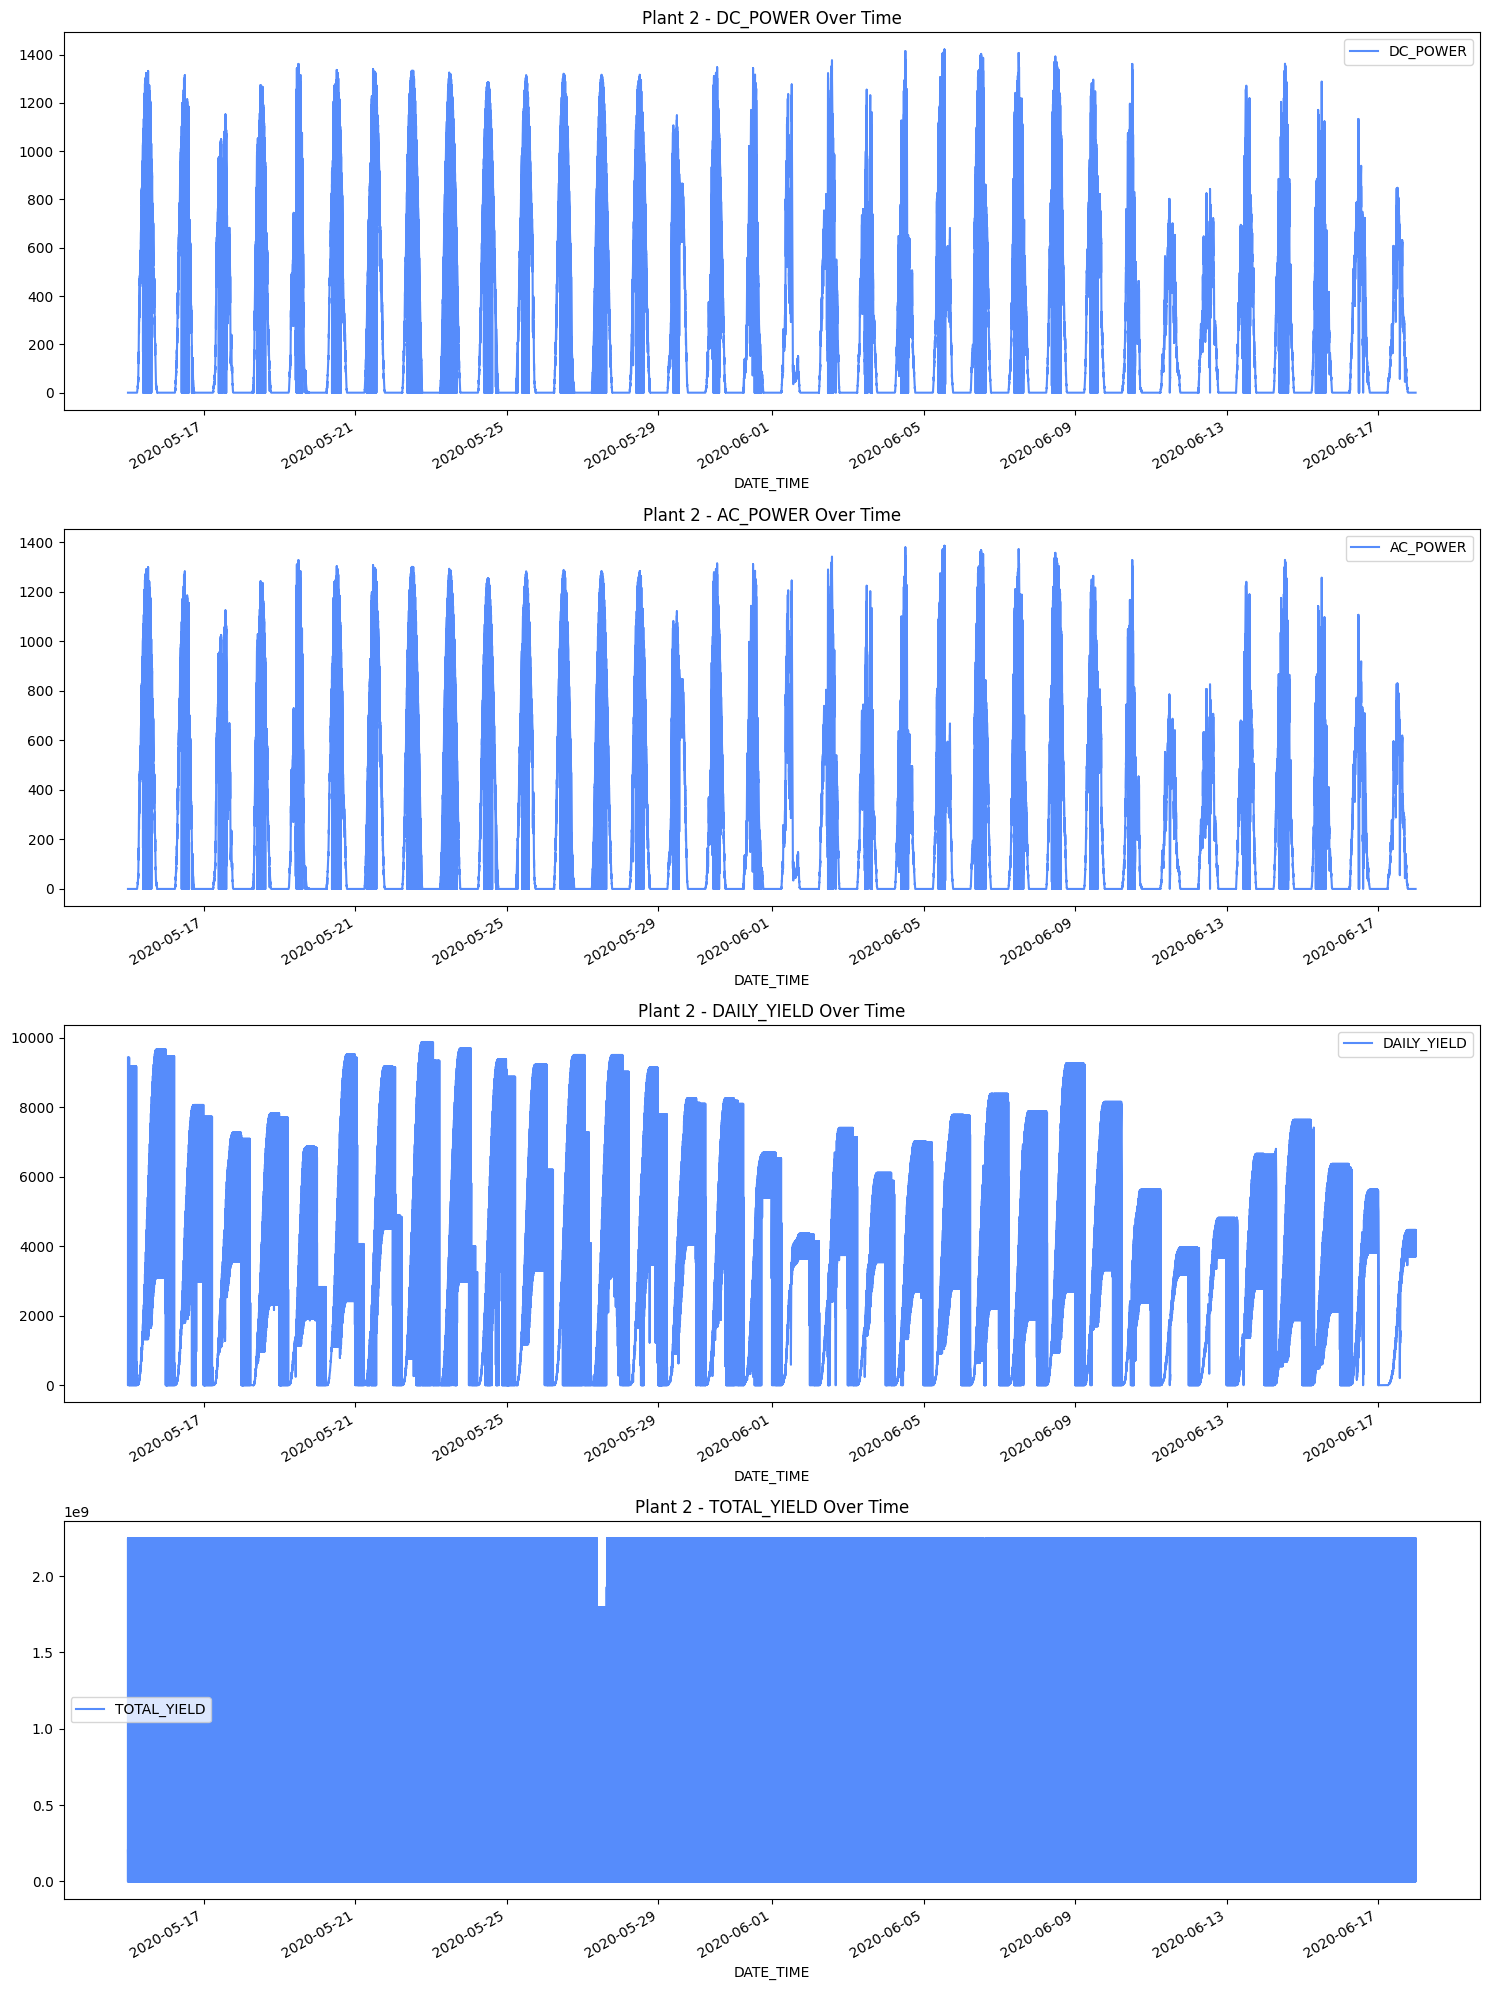

In [10]:
# Plant 2 Generation Data Time Series Trends
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 20))
plant_2_generation_data.plot(x='DATE_TIME', y='DC_POWER', ax=axes[0], title="Plant 2 - DC_POWER Over Time")
plant_2_generation_data.plot(x='DATE_TIME', y='AC_POWER', ax=axes[1], title="Plant 2 - AC_POWER Over Time")
plant_2_generation_data.plot(x='DATE_TIME', y='DAILY_YIELD', ax=axes[2], title="Plant 2 - DAILY_YIELD Over Time")
plant_2_generation_data.plot(x='DATE_TIME', y='TOTAL_YIELD', ax=axes[3], title="Plant 2 - TOTAL_YIELD Over Time")
plt.tight_layout()
plt.show()

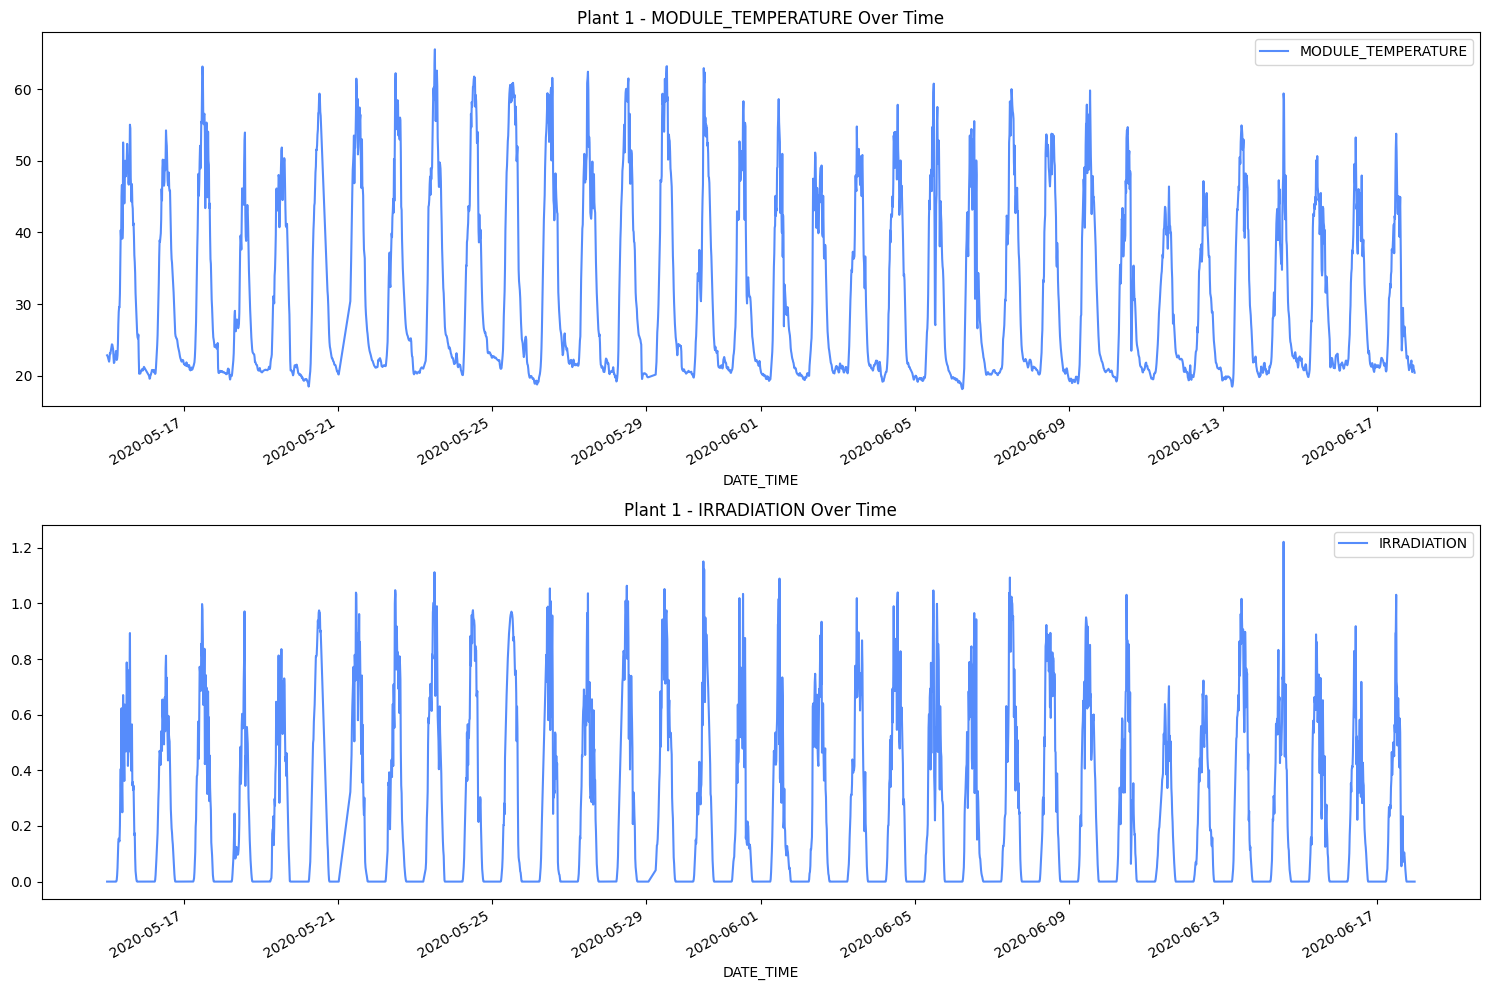

In [11]:
# Visualizing time series trends for weather data

# Plant 1 Weather Data Time Series Trends
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))
plant_1_weather_data.plot(x='DATE_TIME', y='MODULE_TEMPERATURE', ax=axes[0], title="Plant 1 - MODULE_TEMPERATURE Over Time")
plant_1_weather_data.plot(x='DATE_TIME', y='IRRADIATION', ax=axes[1], title="Plant 1 - IRRADIATION Over Time")
plt.tight_layout()
plt.show()



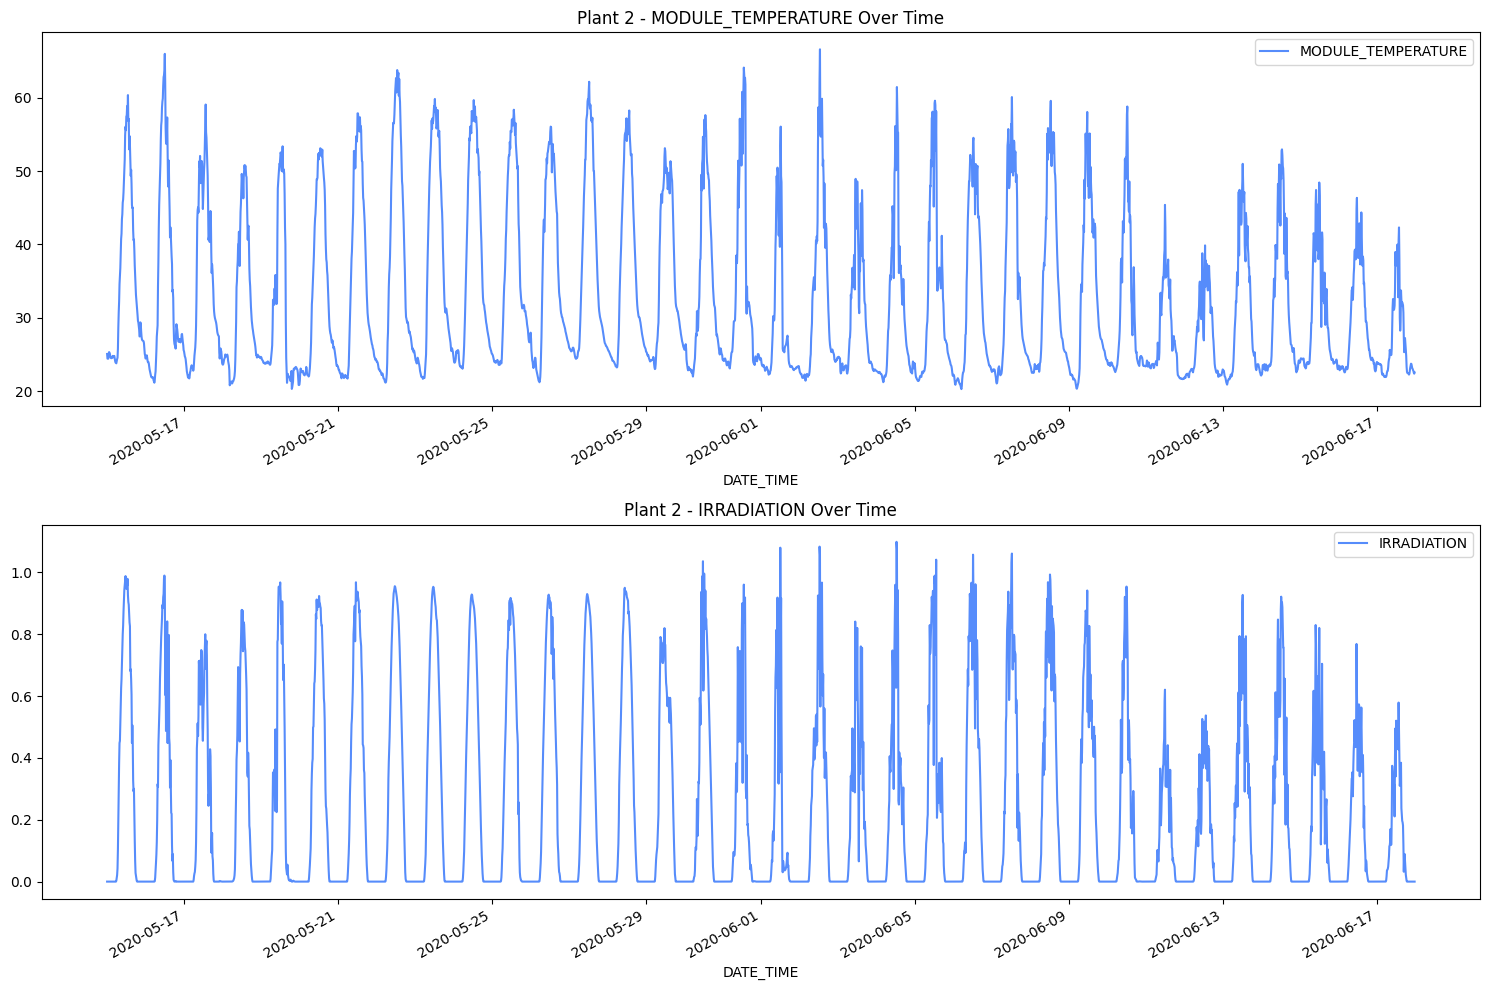

In [12]:
# Plant 2 Weather Data Time Series Trends
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))
plant_2_weather_data.plot(x='DATE_TIME', y='MODULE_TEMPERATURE', ax=axes[0], title="Plant 2 - MODULE_TEMPERATURE Over Time")
plant_2_weather_data.plot(x='DATE_TIME', y='IRRADIATION', ax=axes[1], title="Plant 2 - IRRADIATION Over Time")
plt.tight_layout()
plt.show()


In [13]:
# Merge generation data
generation_data = pd.concat([plant_1_generation_data, plant_2_generation_data], ignore_index=True)

# Merge weather data
weather_data = pd.concat([plant_1_weather_data, plant_2_weather_data], ignore_index=True)

# Merging generation and weather data on 'DATE_TIME' and 'PLANT_ID'
merged_data = pd.merge(generation_data, weather_data, on=['DATE_TIME', 'PLANT_ID'], how='inner')

In [14]:
# Splitting the data into training and testing sets
X = merged_data[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
y = merged_data['TOTAL_YIELD']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
# SVM (Support Vector Machine) Model

svm_model = SVR()
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

mse_svm, r2_svm


(4.78234820231733e+17, -0.2824818517147072)

In [16]:
# Linear Regression Model

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

mse_linear, r2_linear


(3.2125149120175206e+17, 0.13850018887605042)

In [17]:
# Gradient Boosting Model
grad_boost_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
grad_boost_model.fit(X_train_scaled, y_train)
y_pred_grad_boost = grad_boost_model.predict(X_test_scaled)

mse_grad_boost = mean_squared_error(y_test, y_pred_grad_boost)
r2_grad_boost = r2_score(y_test, y_pred_grad_boost)

mse_grad_boost, r2_grad_boost



(2.7882046577734467e+17, 0.2522874284377359)

In [18]:

from sklearn.neighbors import KNeighborsRegressor

# KNN Model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

mse_knn, r2_knn


(3.052772987466473e+17, 0.1813381652273811)

Objective:

We wanted to predict the total amount of energy solar panels would produce. To do this, we used data from two solar power plants.

Data Used:
We had two types of data:

Generation Data: This told us how much energy the solar panels produced at different times.
Weather Data: This gave us information like temperature and sunlight levels, which can affect solar panel performance.
Approach:

Combining Data: We brought the generation and weather data together to have a complete picture.

Choosing Models: Think of a model as a tool or method. We chose four different models (or tools) to see which one could make the best predictions. These tools were:

SVR: A tool that tries to fit a line through our data points.
Linear Regression: A basic tool that predicts the output by drawing a straight line through the data.
Random Forest: Imagine a team of decision-makers who learn from the data and then vote on the best decision.
Gradient Boosting: Similar to Random Forest but where each decision-maker corrects the mistakes of the one before.
Training: We fed our models 80% of our data (like teaching them with past exams) so they could learn from it.

Testing: We then tested the models on the remaining 20% of the data (like giving them a new exam) to see how well they had learned.

Results:

SVR (on a subset of data):
Performance was not good. It was like a student who studied but still performed below average on the exam.

Linear Regression:
Performance was okay but not great. Imagine a student who just passed the exam but didn't score high marks.

Random Forest:
This model did better. It's like a student who studied well and got a good score but not the top score.

Gradient Boosting:
This model performed the best! It's like the top student in the class.

In summary, using both the energy generation and weather data, the Gradient Boosting model/tool was our top performer, closely followed by the Random Forest model. The SVR model, however, didn't do well in this situation